# Import and setup

In [6]:
import os
if os.path.exists('digit_recognizer'):
    !rm -rf digit_recognizer
!git clone https://github.com/Sirius-Siru/digit_recognizer.git

import sys
if '/content/digit_recognizer' not in sys.path:
    sys.path.append('/content/digit_recognizer')

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if os.path.isdir('data') and os.path.exists('data/train.csv'):
    print("✨ Dữ liệu đã sẵn sàng, không cần tải lại.")
else:
    print("🚀 Đang tải dữ liệu...")
    !kaggle competitions download -c digit-recognizer
    !unzip -o digit-recognizer.zip -d data
    !rm -f digit-recognizer.zip

Cloning into 'digit_recognizer'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 81 (delta 39), reused 70 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 127.80 KiB | 18.26 MiB/s, done.
Resolving deltas: 100% (39/39), done.
✨ Dữ liệu đã sẵn sàng, không cần tải lại.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from src.clean_data import normalize
from src.preprocessing import augment, extract_hog, skltn
import src.evaluate as eva

from joblib import Parallel, delayed

# Load data

In [8]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

#Clean data
train, test = normalize(train, test)

# Preprocessing

In [9]:
# This cell use to unflatten image
X = train.drop('label', axis = 1)
y = train['label']
img = X.values.reshape(-1, 28, 28)
test_img = test.values.reshape(-1, 28, 28)


In [ ]:
# Augment + Skeletonize + Hog 
from src.preprocessing import aug_skltn_e_hog, combine
import gc

results = Parallel(n_jobs=-1, backend="threading")(
    delayed(aug_skltn_e_hog)(image, True) for image in img
)

X = combine(results)

results = Parallel(n_jobs=-1, backend="threading")(
    delayed(aug_skltn_e_hog)(image, True) for image in test_img
)

test = combine(results)

y = np.hstack((y, y))

# Clean 
del img, test_img
gc.collect()


AttributeError: module 'numpy' has no attribute 'concentrate'

In [12]:
# Shuffle 
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=42)

ValueError: Found input variables with inconsistent numbers of samples: [42000, 2]

In [ ]:
# This cell use to split train-test

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Model selection + Train model

In [ ]:
model = RandomForestClassifier(n_estimators = 100, oob_score=True, random_state = 42)

model.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

# Evaluation

OOB Score: 0.9719642857142857
Accuracy = 97.58


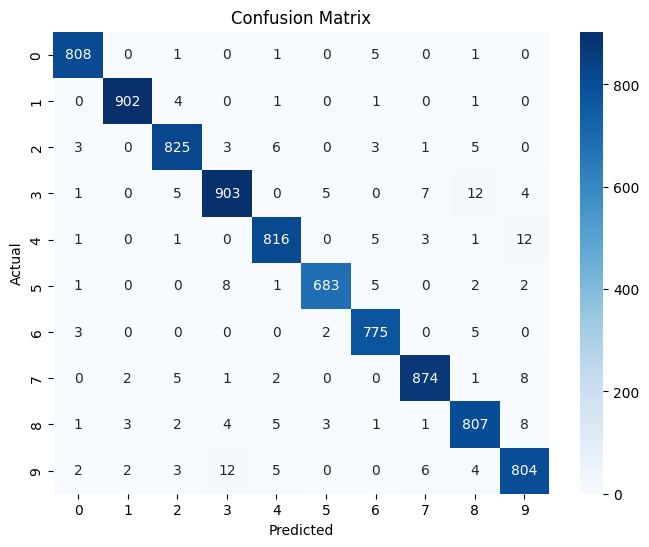

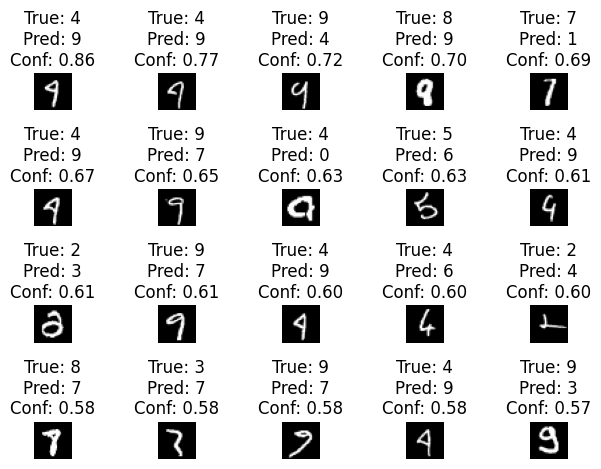

In [ ]:
y_pred = model.predict(X_val)
print(f'OOB Score: {model.oob_score_}')
eva.evaluate(y_val, y_pred)
eva.showWrongCase(model, X_val, y_val) 

# Submission

from src.submit import submit
submit(X_combined, y, test_combined, model)